## Random Forest

## Step 1

In [16]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, RandomizedSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score,
    precision_score, recall_score, accuracy_score
)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
CLASS_ORDER  = ['Bad', 'Mixed', 'Good']

print('Libraries loaded')

Libraries loaded


## Step 2

In [17]:
X_train = pd.read_csv('../Datasets/X_train_multiclass_safe.csv')
y_train = pd.read_csv('../Datasets/y_train_multiclass.csv').squeeze()

X_test  = pd.read_csv('../Datasets/X_test_multiclass_safe.csv')
y_test  = pd.read_csv('../Datasets/y_test_multiclass.csv').squeeze()

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print()
print('Train class distribution:')
print(y_train.value_counts()[CLASS_ORDER])
print()
print('Test class distribution:')
print(y_test.value_counts()[CLASS_ORDER])

X_train : (45324, 147)
X_test  : (11331, 147)

Train class distribution:
label_multiclass
Bad       3819
Mixed    12834
Good     28671
Name: count, dtype: int64

Test class distribution:
label_multiclass
Bad       955
Mixed    3208
Good     7168
Name: count, dtype: int64


## Step 3 - Baseline: Majority Class Classifier

Before training any real model, we first create a very simple baseline
to compare against. This baseline always predicts the most frequent
class, in our case "Good", no matter what the input is.

*Note: A baseline analysis is provided in the team's baseline
notebook. This section serves as a reference point for comparison.*

We use **macro-averaged F1** as our main metric because the dataset is
not balanced. Good games make up 63% of the data, Mixed 28%, and Bad
only 8%. If we used accuracy instead, a model that always predicts Good
would score 63% and look reasonable, even though it never identifies Bad or
Mixed games at all. Macro-F1 treats all three classes equally so we get
a more honest picture of performance.

In [18]:
baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

baseline_f1   = f1_score(y_test, y_pred_baseline, average='macro', labels=CLASS_ORDER)
baseline_prec = precision_score(y_test, y_pred_baseline, average='macro',
                                labels=CLASS_ORDER, zero_division=0)
baseline_rec  = recall_score(y_test, y_pred_baseline, average='macro',
                              labels=CLASS_ORDER, zero_division=0)

print('BASELINE: Majority Class Classifier')
print(classification_report(y_test, y_pred_baseline, labels=CLASS_ORDER,
                             target_names=CLASS_ORDER, zero_division=0))
print(f'Baseline Macro-F1       : {baseline_f1:.4f}')
print(f'Baseline Macro-Precision: {baseline_prec:.4f}')
print(f'Baseline Macro-Recall   : {baseline_rec:.4f}')

BASELINE: Majority Class Classifier
              precision    recall  f1-score   support

         Bad       0.00      0.00      0.00       955
       Mixed       0.00      0.00      0.00      3208
        Good       0.63      1.00      0.77      7168

    accuracy                           0.63     11331
   macro avg       0.21      0.33      0.26     11331
weighted avg       0.40      0.63      0.49     11331

Baseline Macro-F1       : 0.2583
Baseline Macro-Precision: 0.2109
Baseline Macro-Recall   : 0.3333


## Step 4 - Default Random Forest + Cross Validation

We train a Random Forest with default settings and measure its performance in two ways:

1. **5-fold cross-validation on the training set** the training data is split into 5 parts. Each time, we train on 4 parts and test on the 1 remaining part. We do this 5 times so every part gets tested once. This gives a stable estimate of how well the model generalises.

2. **Test-set evaluation** we also fit the default model on the full training set and predict on the held-out test data. This way, all models in the final comparison table are measured on exactly the same test set.

Key choices:
- `class_weight='balanced'` tells the model to pay more attention to Bad and Mixed games, which are much rarer than Good games in the data.
- We use **macro-averaged F1** as the scoring metric so that the minority classes count equally.

In [19]:
rf_default = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    rf_default, X_train, y_train,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

print('5-fold Cross-Validation (macro-F1):')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Mean : {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}')

# Also evaluate on the test set for a fair final comparison
rf_default.fit(X_train, y_train)
y_pred_default = rf_default.predict(X_test)

default_f1   = f1_score(y_test, y_pred_default, average='macro', labels=CLASS_ORDER)
default_prec = precision_score(y_test, y_pred_default, average='macro', labels=CLASS_ORDER, zero_division=0)
default_rec  = recall_score(y_test, y_pred_default, average='macro', labels=CLASS_ORDER, zero_division=0)

print()
print('Default RF — Test Set Results:')
print(classification_report(y_test, y_pred_default, labels=CLASS_ORDER,
                             target_names=CLASS_ORDER))
print(f'Default RF macro-F1 (test)       : {default_f1:.4f}')
print(f'Default RF macro-Precision (test): {default_prec:.4f}')
print(f'Default RF macro-Recall (test)   : {default_rec:.4f}')
print(f'Baseline (DummyClassifier)       : {baseline_f1:.4f}')

5-fold Cross-Validation (macro-F1):
  Fold 1: 0.4331
  Fold 2: 0.4490
  Fold 3: 0.4327
  Fold 4: 0.4323
  Fold 5: 0.4309
  Mean : 0.4356  ±  0.0068

Default RF — Test Set Results:
              precision    recall  f1-score   support

         Bad       0.44      0.12      0.19       955
       Mixed       0.49      0.24      0.33      3208
        Good       0.70      0.92      0.80      7168

    accuracy                           0.66     11331
   macro avg       0.54      0.43      0.44     11331
weighted avg       0.62      0.66      0.61     11331

Default RF macro-F1 (test)       : 0.4361
Default RF macro-Precision (test): 0.5420
Default RF macro-Recall (test)   : 0.4288
Baseline (DummyClassifier)       : 0.2583


## Step 5 - Feature Importance

After training, we can ask the Random Forest which features it found most useful when making decisions.

Each feature gets a score based on how much it helped the model split the data into the right classes. A higher score means the feature was more useful.

We plot the top 20 features to see what kind of game information matters most for predicting whether a game will be received well.

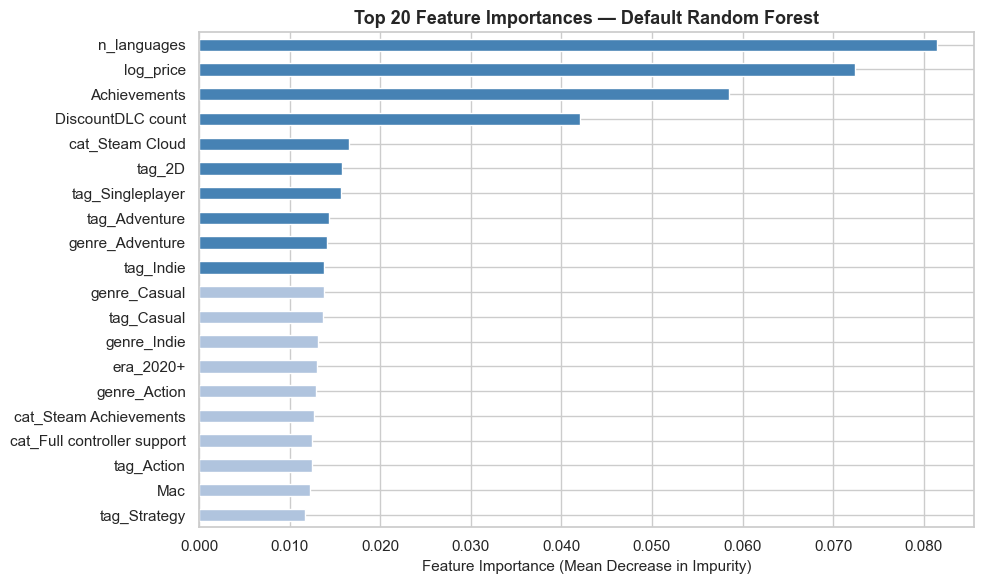


Top 20 features:
n_languages                    0.0815
log_price                      0.0724
Achievements                   0.0585
DiscountDLC count              0.0421
cat_Steam Cloud                0.0165
tag_2D                         0.0157
tag_Singleplayer               0.0156
tag_Adventure                  0.0143
genre_Adventure                0.0141
tag_Indie                      0.0138
genre_Casual                   0.0138
tag_Casual                     0.0137
genre_Indie                    0.0131
era_2020+                      0.0130
genre_Action                   0.0129
cat_Steam Achievements         0.0126
cat_Full controller support    0.0124
tag_Action                     0.0124
Mac                            0.0122
tag_Strategy                   0.0116


In [20]:
importances = pd.Series(rf_default.feature_importances_, index=X_train.columns)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if i < 10 else 'lightsteelblue' for i in range(20)]
top20[::-1].plot(kind='barh', ax=ax, color=colors[::-1], edgecolor='white')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title('Top 20 Feature Importances — Default Random Forest', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 20 features:')
print(top20.round(4).to_string())

## Step 6 - Hyperparameter Tuning

A Random Forest has settings that control how it learns, for ex. how many trees to build or how deep each tree can grow. These are called hyperparameters.

Instead of trying every possible combination (which would take too long), we randomly try 20 different combinations and test each one using cross-validation. This method is called RandomizedSearchCV. At the end, it gives us the combination that produced the best macro-F1 score.

Settings we tested:
- `n_estimators`  how many trees to build (100, 200, 300, or 500)
- `max_depth`  how deep each tree can grow (no limit, or 10 / 20 / 30 / 50)
- `min_samples_leaf`  minimum number of samples required at the end of a branch (1, 2, 5, or 10)
- `max_features` how many features each tree considers at each split (sqrt, log2, or 30%)

In [21]:
param_dist = {
    'n_estimators'    : [100, 200, 300, 500],
    'max_depth'       : [None, 10, 20, 30, 50],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features'    : ['sqrt', 'log2', 0.3]
}

rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(f'\nBest macro-F1 (CV): {search.best_score_:.4f}')
print('Best parameters:')
for k, v in search.best_params_.items():
    print(f'  {k:25s}: {v}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best macro-F1 (CV): 0.5081
Best parameters:
  n_estimators             : 200
  min_samples_leaf         : 5
  max_features             : sqrt
  max_depth                : None


## Step 7 - Final Model Evaluation on Test Set

We now test the best model from Step 6 on data it has never seen before: the held-out test set.
This is the most honest way to measure real performance because the model had no access to this data during training or tuning.

We report:
- A full classification report showing precision, recall, and F1 for each class separately
- Macro averaged precision, recall, and F1 across all three classes
- A confusion matrix showing which classes the model gets right and which ones it confuses

FINAL MODEL: Tuned Random Forest (Baseline Data)
              precision    recall  f1-score   support

         Bad       0.28      0.41      0.34       955
       Mixed       0.44      0.42      0.43      3208
        Good       0.78      0.75      0.76      7168

    accuracy                           0.63     11331
   macro avg       0.50      0.53      0.51     11331
weighted avg       0.64      0.63      0.63     11331

Dummy Baseline macro-F1    : 0.2583
Default RF macro-F1 (test) : 0.4361
Tuned RF macro-F1 (test)   : 0.5110
Tuned RF macro-Precision   : 0.5024
Tuned RF macro-Recall      : 0.5273


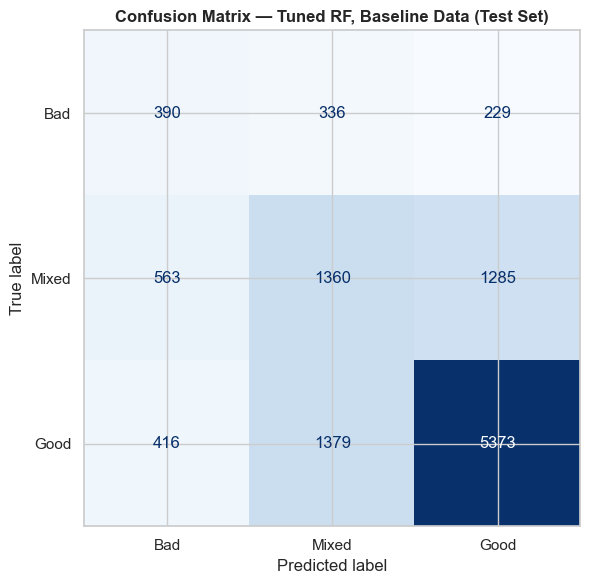

In [23]:
best_rf = search.best_estimator_
y_pred  = best_rf.predict(X_test)

print('FINAL MODEL: Tuned Random Forest (Baseline Data)')
print(classification_report(y_test, y_pred,
                             labels=CLASS_ORDER,
                             target_names=CLASS_ORDER))

final_f1   = f1_score(y_test, y_pred, average='macro', labels=CLASS_ORDER)
final_prec = precision_score(y_test, y_pred, average='macro', labels=CLASS_ORDER, zero_division=0)
final_rec  = recall_score(y_test, y_pred, average='macro', labels=CLASS_ORDER, zero_division=0)

print(f'Dummy Baseline macro-F1    : {baseline_f1:.4f}')
print(f'Default RF macro-F1 (test) : {default_f1:.4f}')
print(f'Tuned RF macro-F1 (test)   : {final_f1:.4f}')
print(f'Tuned RF macro-Precision   : {final_prec:.4f}')
print(f'Tuned RF macro-Recall      : {final_rec:.4f}')

cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=CLASS_ORDER).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Tuned RF, Baseline Data (Test Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_rf_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8 - ROS Comparison (Random Over Sampling)

One way to handle class imbalance is Random Over Sampling (ROS).
ROS makes copies of the minority class samples (Bad and Mixed games) until all three classes have the same number of training examples.

We use the same hyperparameters found in Step 6 so the comparison is controlled. The only thing that changes is the training data, not the model settings.

**Note on class_weight:** We don't use `class_weight='balanced'` here. ROS already balances the training data, so applying class_weight on top would double-compensate and make the model unfairly biased toward the minority classes.

The test set stays exactly the same across all experiments. We never change the test data.

ROS train class distribution:
label_multiclass
Bad      28671
Mixed    28671
Good     28671
Name: count, dtype: int64

 ROS: Tuned Random Forest 
              precision    recall  f1-score   support

         Bad       0.29      0.37      0.33       955
       Mixed       0.44      0.44      0.44      3208
        Good       0.78      0.75      0.76      7168

    accuracy                           0.63     11331
   macro avg       0.50      0.52      0.51     11331
weighted avg       0.64      0.63      0.64     11331

Tuned RF (Baseline) macro-F1 : 0.5110
Tuned RF + ROS macro-F1      : 0.5117
Tuned RF + ROS macro-Prec    : 0.5047
Tuned RF + ROS macro-Rec     : 0.5219


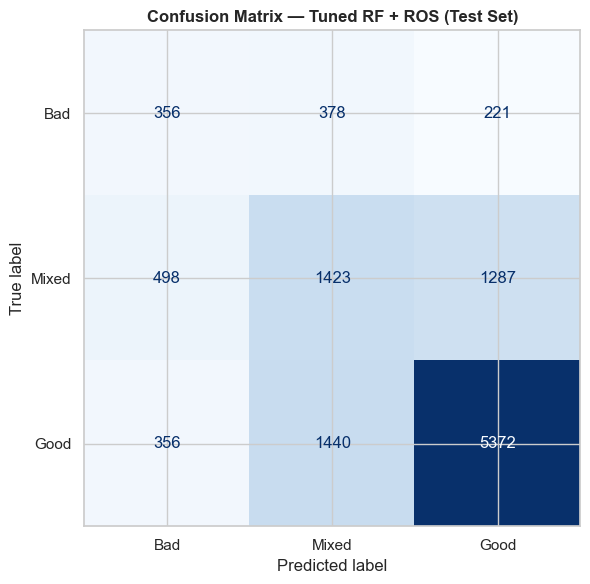

In [25]:
X_train_ros = pd.read_csv('../Datasets/X_train_multiclass_ros.csv')
y_train_ros = pd.read_csv('../Datasets/y_train_multiclass_ros.csv').squeeze()

print('ROS train class distribution:')
print(y_train_ros.value_counts()[CLASS_ORDER])

# No class_weight='balanced' - ROS already balances the training data
rf_ros = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=5,
    max_features='sqrt',
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_ros.fit(X_train_ros, y_train_ros)
y_pred_ros = rf_ros.predict(X_test)

print('\n ROS: Tuned Random Forest ')
print(classification_report(y_test, y_pred_ros,
                             labels=CLASS_ORDER,
                             target_names=CLASS_ORDER))

ros_f1   = f1_score(y_test, y_pred_ros, average='macro', labels=CLASS_ORDER)
ros_prec = precision_score(y_test, y_pred_ros, average='macro', labels=CLASS_ORDER, zero_division=0)
ros_rec  = recall_score(y_test, y_pred_ros, average='macro', labels=CLASS_ORDER, zero_division=0)

print(f'Tuned RF (Baseline) macro-F1 : {final_f1:.4f}')
print(f'Tuned RF + ROS macro-F1      : {ros_f1:.4f}')
print(f'Tuned RF + ROS macro-Prec    : {ros_prec:.4f}')
print(f'Tuned RF + ROS macro-Rec     : {ros_rec:.4f}')

cm_ros = confusion_matrix(y_test, y_pred_ros, labels=CLASS_ORDER)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_ros,
                       display_labels=CLASS_ORDER).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Tuned RF + ROS (Test Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_rf_ros.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9 - SMOTE Comparison (Synthetic Minority Over-Sampling)

SMOTE is another method for handling class imbalance.
Instead of just copying existing minority samples like ROS does, SMOTE creates new artificial samples by blending similar games together.

For example, if two Bad games have similar feature values, SMOTE generates a new game in between them and also labels it as Bad. This gives the model more variety to learn from, rather than seeing the same repeated samples.

We again use the same hyperparameters from Step 6 and the same fixed test set.
`class_weight='balanced'` is also removed here for the same reason as in Step 8, SMOTE already produces a balanced training set.

SMOTE train class distribution:
label_multiclass
Bad      28671
Mixed    28671
Good     28671
Name: count, dtype: int64

SMOTE: Tuned Random Forest 
              precision    recall  f1-score   support

         Bad       0.29      0.34      0.31       955
       Mixed       0.45      0.40      0.42      3208
        Good       0.76      0.77      0.77      7168

    accuracy                           0.63     11331
   macro avg       0.50      0.51      0.50     11331
weighted avg       0.63      0.63      0.63     11331

Tuned RF (Baseline) macro-F1  : 0.5110
Tuned RF + ROS macro-F1       : 0.5117
Tuned RF + SMOTE macro-F1     : 0.5013
Tuned RF + SMOTE macro-Prec   : 0.4988
Tuned RF + SMOTE macro-Rec    : 0.5056


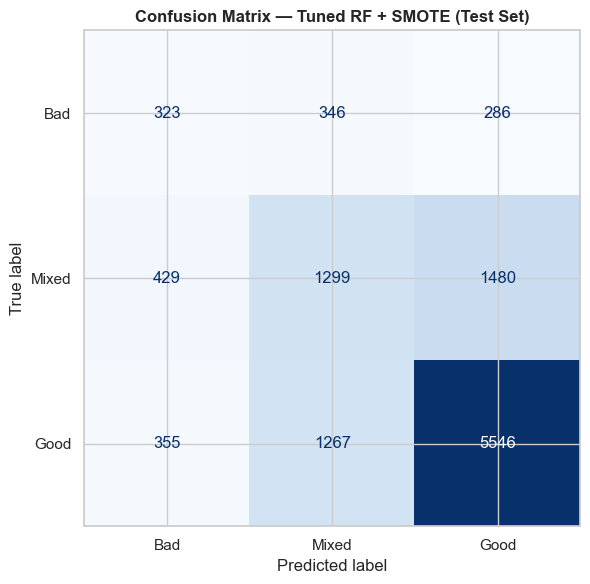

In [26]:
X_train_smote = pd.read_csv('../Datasets/X_train_multiclass_smote.csv')
y_train_smote = pd.read_csv('../Datasets/y_train_multiclass_smote.csv').squeeze()

print('SMOTE train class distribution:')
print(y_train_smote.value_counts()[CLASS_ORDER])

# No class_weight='balanced' - SMOTE already balances the training data
rf_smote = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=5,
    max_features='sqrt',
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_smote.predict(X_test)

print('\nSMOTE: Tuned Random Forest ')
print(classification_report(y_test, y_pred_smote,
                             labels=CLASS_ORDER,
                             target_names=CLASS_ORDER))

smote_f1   = f1_score(y_test, y_pred_smote, average='macro', labels=CLASS_ORDER)
smote_prec = precision_score(y_test, y_pred_smote, average='macro', labels=CLASS_ORDER, zero_division=0)
smote_rec  = recall_score(y_test, y_pred_smote, average='macro', labels=CLASS_ORDER, zero_division=0)

print(f'Tuned RF (Baseline) macro-F1  : {final_f1:.4f}')
print(f'Tuned RF + ROS macro-F1       : {ros_f1:.4f}')
print(f'Tuned RF + SMOTE macro-F1     : {smote_f1:.4f}')
print(f'Tuned RF + SMOTE macro-Prec   : {smote_prec:.4f}')
print(f'Tuned RF + SMOTE macro-Rec    : {smote_rec:.4f}')

cm_smote = confusion_matrix(y_test, y_pred_smote, labels=CLASS_ORDER)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_smote,
                       display_labels=CLASS_ORDER).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Tuned RF + SMOTE (Test Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_rf_smote.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10 - Final Comparison Summary

Here we put all results side by side to see which setup worked best.

We compare five models, **all measured on the same held-out test set**:
- Majority Class Baseline: always predicts "Good"
- Default RF: untuned model, evaluated on the test set
- Tuned RF (Baseline): best model from Step 6, trained on the original imbalanced data with `class_weight='balanced'`
- Tuned RF + ROS: same tuned settings, trained on ROS-balanced data, no `class_weight`
- Tuned RF + SMOTE: same tuned settings, trained on SMOTE-balanced data, no `class_weight`

The table reports macro-averaged **precision**, **recall**, and **F1** for each model.

**Note on hyperparameter reuse:** The hyperparameters from Step 6 are reused for ROS and SMOTE on purpose. This way we isolate the effect of the resampling method itself, the model settings are held constant.

**Note on resampling:** In these experiments, ROS and SMOTE did not clearly improve results over the baseline setup. This suggests that Random Forest with `class_weight='balanced'` may already be handling the class imbalance well enough. However, this conclusion should be read together with the full precision, recall and F1 scores in the table below, not from macro-F1 alone.

In [27]:
results = pd.DataFrame({
    'Model'          : ['Majority Class Baseline', 'Default RF (test)',
                        'Tuned RF (Baseline)', 'Tuned RF + ROS', 'Tuned RF + SMOTE'],
    'Training Data'  : ['baseline', 'baseline', 'baseline', 'ROS', 'SMOTE'],
    'class_weight'   : ['balanced', 'balanced', 'balanced', 'none', 'none'],
    'Macro-Precision': [baseline_prec, default_prec, final_prec, ros_prec, smote_prec],
    'Macro-Recall'   : [baseline_rec,  default_rec,  final_rec,  ros_rec,  smote_rec],
    'Macro-F1'       : [baseline_f1,   default_f1,   final_f1,   ros_f1,   smote_f1],
})

for col in ['Macro-Precision', 'Macro-Recall', 'Macro-F1']:
    results[col] = results[col].round(4)

print('='*90)
print('FINAL MODEL COMPARISON SUMMARY  (all metrics on held-out test set)')
print('='*90)
print(results.to_string(index=False))
print('='*90)
print()
print('Best hyperparameters (reused for ROS and SMOTE — controlled comparison):')
for k, v in search.best_params_.items():
    print(f'  {k:25s}: {v}')

# Save prediction files for team comparison
pd.DataFrame({'y_true': y_test.values, 'y_pred': y_pred_default}).to_csv(
    'rf_default_predictions.csv', index=False)
pd.DataFrame({'y_true': y_test.values, 'y_pred': y_pred}).to_csv(
    'rf_baseline_predictions.csv', index=False)
pd.DataFrame({'y_true': y_test.values, 'y_pred': y_pred_ros}).to_csv(
    'rf_ros_predictions.csv', index=False)
pd.DataFrame({'y_true': y_test.values, 'y_pred': y_pred_smote}).to_csv(
    'rf_smote_predictions.csv', index=False)
results.to_csv('rf_results_summary.csv', index=False)

print()
print('Saved prediction files:')
print('  rf_default_predictions.csv')
print('  rf_baseline_predictions.csv')
print('  rf_ros_predictions.csv')
print('  rf_smote_predictions.csv')
print('  rf_results_summary.csv')

FINAL MODEL COMPARISON SUMMARY  (all metrics on held-out test set)
                  Model Training Data class_weight  Macro-Precision  Macro-Recall  Macro-F1
Majority Class Baseline      baseline     balanced           0.2109        0.3333    0.2583
      Default RF (test)      baseline     balanced           0.5420        0.4288    0.4361
    Tuned RF (Baseline)      baseline     balanced           0.5024        0.5273    0.5110
         Tuned RF + ROS           ROS         none           0.5047        0.5219    0.5117
       Tuned RF + SMOTE         SMOTE         none           0.4988        0.5056    0.5013

Best hyperparameters (reused for ROS and SMOTE — controlled comparison):
  n_estimators             : 200
  min_samples_leaf         : 5
  max_features             : sqrt
  max_depth                : None

Saved prediction files:
  rf_default_predictions.csv
  rf_baseline_predictions.csv
  rf_ros_predictions.csv
  rf_smote_predictions.csv
  rf_results_summary.csv
